In [268]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [269]:
# !pip install ucimlrepo matplotlib seaborn pandas numpy
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
import sys


In [270]:
#load and summary

# Fetch dataset
heart_disease = fetch_ucirepo(id=45)

# Extraer features (X) y target (y)
X = heart_disease.data.features
y = heart_disease.data.targets

print(f"Shape (Features): {X.shape}")
print(f"Shape (Target): {y.shape}\n")

print("data types:")
print(X.dtypes)

print("\nvariables:")
print(heart_disease.variables)

print("descriptive analysis:")
display(X.describe())

print(X.head(5))




Shape (Features): (303, 13)
Shape (Target): (303, 1)

data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

variables:
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [271]:
# missing values

#show where are the NA
print("missing values before imputation: ")
print(X.isnull().sum()[X.isnull().sum() > 0])


#standarize before KNN and clustering
scaler = StandardScaler()
X_scaled_temp = scaler.fit_transform(X)

#apply KNN to scaled data
knn_imputer = KNNImputer(n_neighbors=5)
X_clean_scaled_temp = knn_imputer.fit_transform(X_scaled_temp)

#undo the scaling
X_clean_original_scale = scaler.inverse_transform(X_clean_scaled_temp)

#conver to final dataset
X_clean = pd.DataFrame(X_clean_original_scale, columns=X.columns)

print("missing values after imputation: ", X_clean.isnull().sum().sum())
print(X_clean.head(3))


missing values before imputation: 
ca      4
thal    2
dtype: int64
missing values after imputation:  0
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  


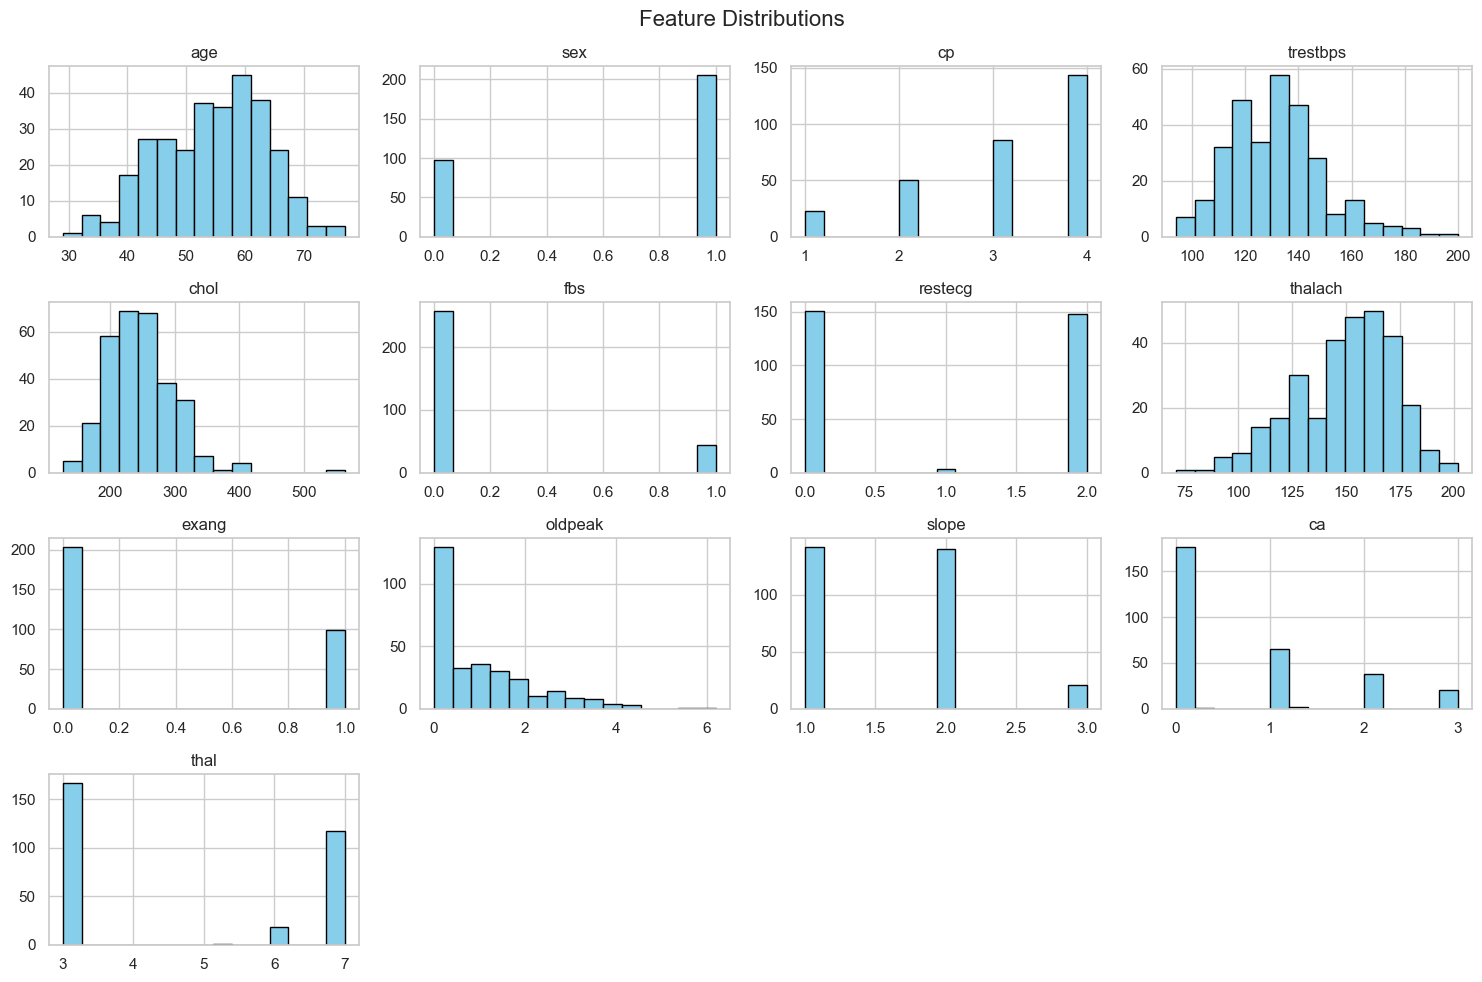

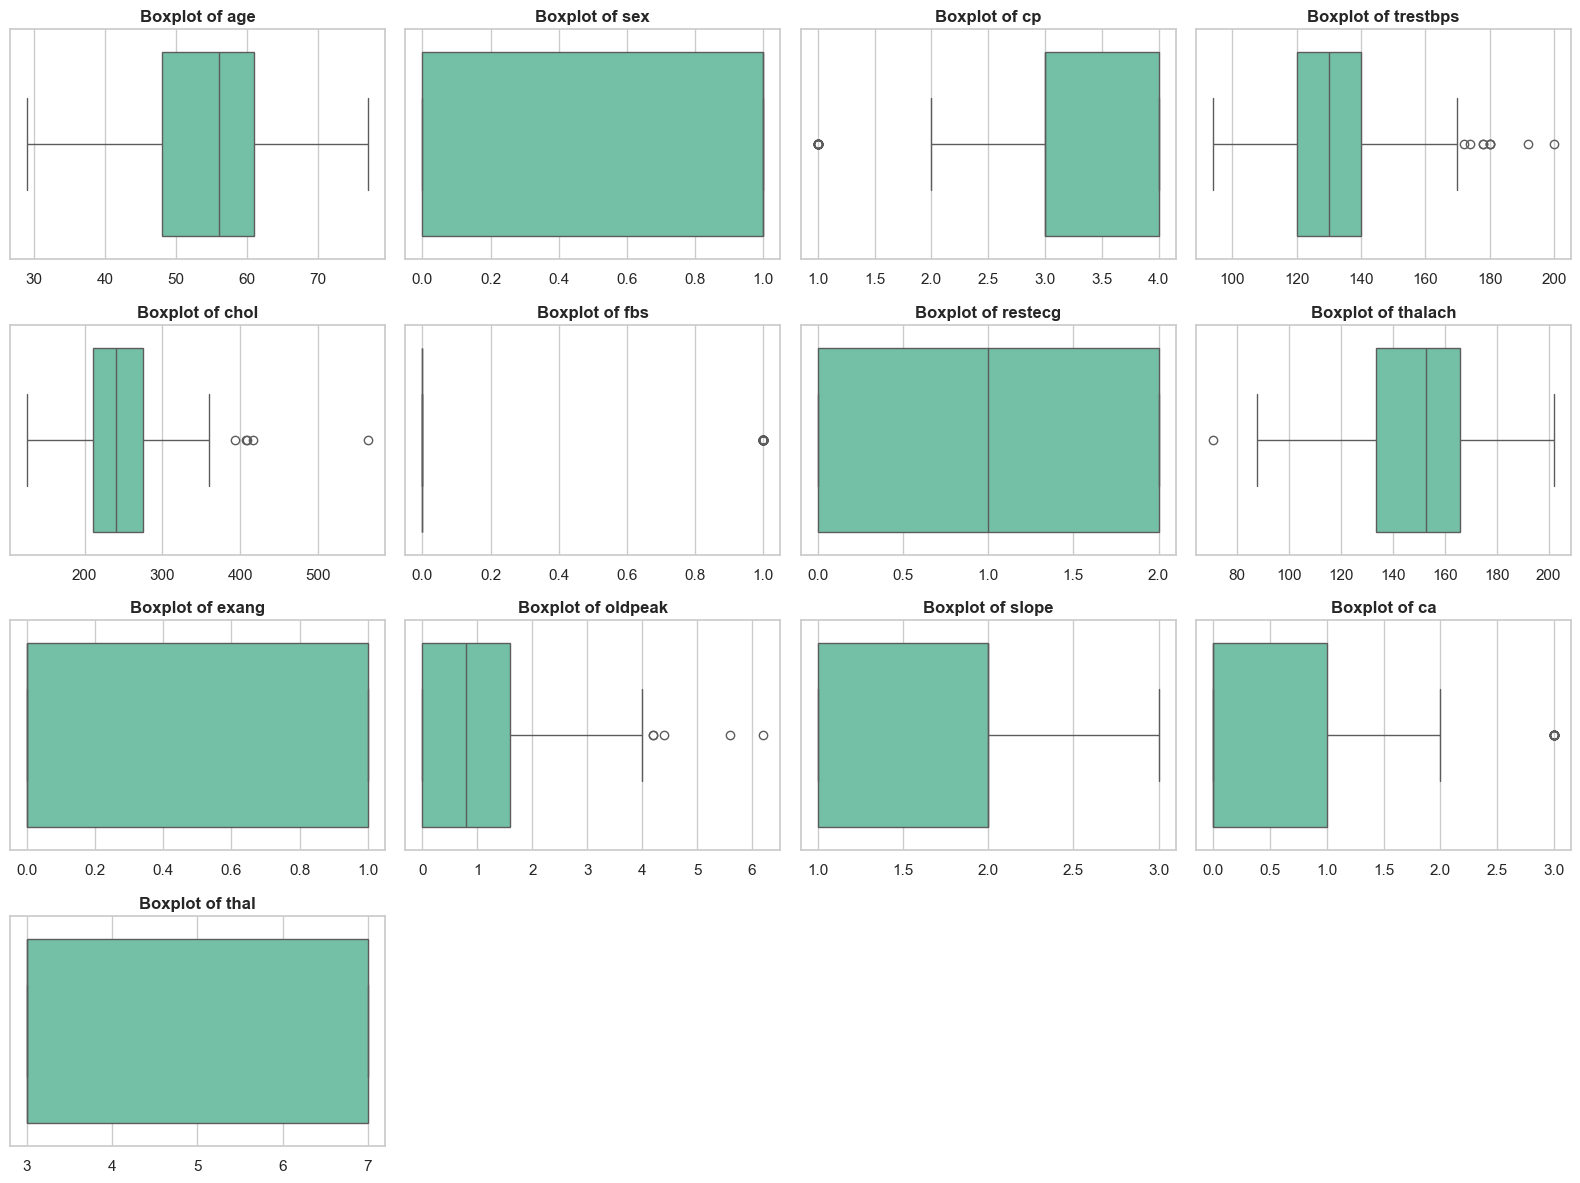

In [272]:
#plots

sns.set_theme(style="whitegrid")

#histograms
X_clean.hist(bins=15, figsize=(15, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

#boxplots
#compute rows and columns for the grid
columns = X_clean.columns
num_cols = len(columns)
cols_per_row = 4
num_rows = math.ceil(num_cols / cols_per_row)

#create the figure and axes
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(16, 12))
axes = axes.flatten()

#drawing bloxplots
for i, col in enumerate(columns):
    sns.boxplot(x=X_clean[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f"Boxplot of {col}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

#erase empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

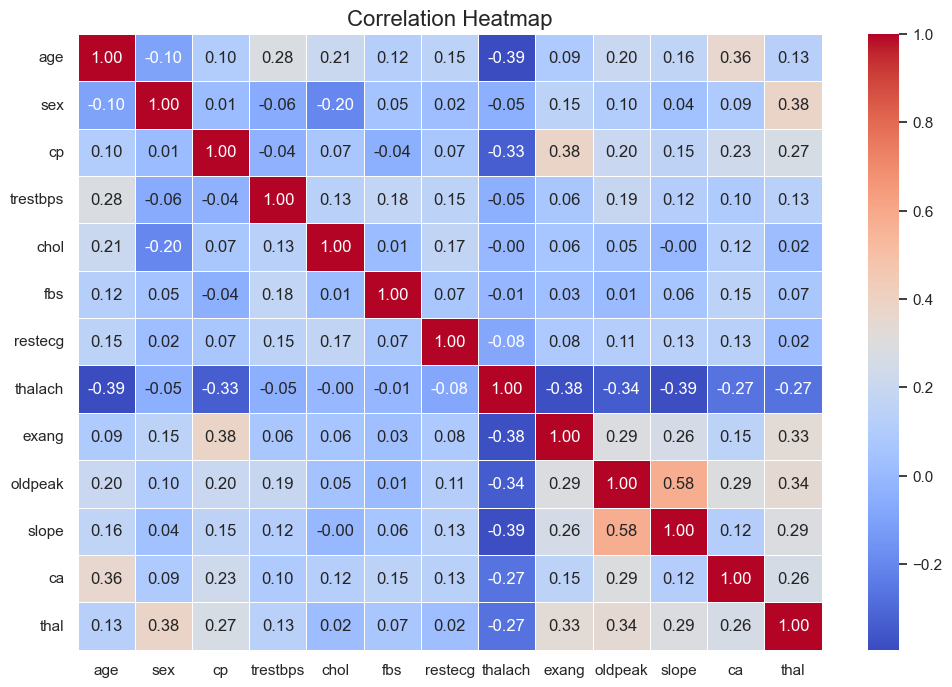

In [273]:
#correlation heatmap

plt.figure(figsize=(12, 8))
corr_matrix = X_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [274]:
#saving the final datset
X_clean.to_csv('task1_cleaned.csv', index=False)
#target
y.to_csv('targets.csv', index=False)

## Task 2 — Preprocessing & Feature Engineering

In this section, the dataset is prepared for clustering through encoding, scaling, dimensionality reduction (PCA), and supervised feature selection.

The target variable is treated as hidden during clustering and is only used for feature selection, as permitted by the assignment.

### Data Preparation

The cleaned feature dataset and target variable are loaded separately and then combined for preprocessing.

The target variable is binarised into:
- 0 → No heart disease
- 1 → Presence of heart disease

This simplifies evaluation while preserving clinical meaning.

In [275]:
# Load files
X = pd.read_csv("task1_cleaned.csv")
y = pd.read_csv("targets.csv")

# If y has no column name, fix it
y.columns = ["target"]

# Combine
df = X.copy()
df["target"] = y["target"]

print(df.head())
print(df.columns)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


The dataset is split into features (X) and target (y). 

The target variable is not used in clustering, but is required later for supervised feature selection.

In [276]:
X = df.drop("target", axis=1)
y = df["target"]

# Binarize target
y = (y > 0).astype(int)

### Encoding Categorical Variables

Categorical features (`cp`, `restecg`, `slope`, `thal`) are transformed using one-hot encoding.

This method is chosen over label encoding because:
- It avoids introducing artificial ordinal relationships
- It allows clustering algorithms to treat categories independently

The first category is dropped to avoid redundancy.

In [277]:
# Define categorical columns
categorical_cols = ["cp", "restecg", "slope", "thal"]

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True).astype(int)

# Check result
X_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_5.2,thal_6.0,thal_7.0
0,63,1,145,233,1,150,0,2,0,0,0,0,0,1,0,1,0,1,0
1,67,1,160,286,0,108,1,1,3,0,0,1,0,1,1,0,0,0,0
2,67,1,120,229,0,129,1,2,2,0,0,1,0,1,1,0,0,0,1
3,37,1,130,250,0,187,0,3,0,0,1,0,0,0,0,1,0,0,0
4,41,0,130,204,0,172,0,1,0,1,0,0,0,1,0,0,0,0,0


### Feature Scaling

Features are standardised using StandardScaler.

This is necessary because:
- PCA is variance-based and sensitive to scale
- Clustering algorithms (e.g., K-Means) rely on distance calculations

Scaling ensures that all features contribute equally and prevents features with larger magnitudes from dominating.

In [278]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split BEFORE scaling (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale full dataset for PCA visualization
X_scaled = scaler.fit_transform(X_encoded)

### Principal Component Analysis (PCA)

PCA is applied to understand the variance structure of the dataset and to reduce dimensionality for visualization.

The cumulative explained variance plot helps determine how many components are needed to retain most of the information.

In [279]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

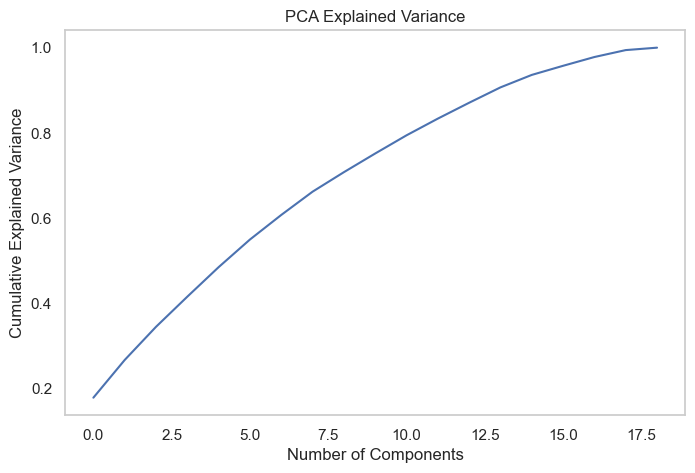

In [280]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

The plot shows that approximately 13 components are required to retain at least 85% of the total variance.

This indicates that the dataset has moderate complexity and that many features contribute meaningful information.

In [281]:
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", pca.n_components_)

Number of components selected: 13


By setting `n_components = 0.85`, PCA automatically selects the minimum number of components required to retain 85% of the variance.

This results in 13 components, meaning only limited dimensionality reduction is possible without significant information loss.

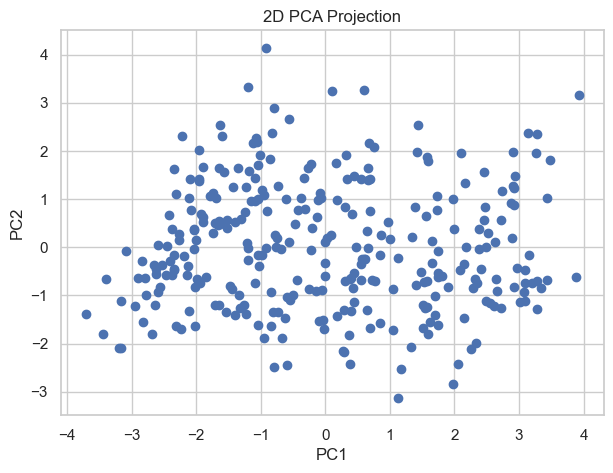

In [282]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection")
plt.show()

The 2D PCA projection provides a visual representation of the dataset in reduced dimensions.

The data points do not form clearly separable clusters, suggesting that the underlying structure may not be strongly clusterable in low-dimensional space.

This indicates that clustering algorithms may struggle to find well-separated groups.

### Feature Selection

Supervised feature selection is performed using SelectKBest with the ANOVA F-test.

This is the only step where the target variable is used, as allowed in the assignment.

The method selects features that have the strongest statistical relationship with the target variable.

In [283]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top k features
k = 8
selector = SelectKBest(score_func=f_classif, k=k)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)

selected_features = X_encoded.columns[selector.get_support()]

print("Selected features:")
print(selected_features)

Selected features:
Index(['thalach', 'exang', 'oldpeak', 'ca', 'cp_3.0', 'cp_4.0', 'slope_2.0',
       'thal_7.0'],
      dtype='object')


The top 8 features were selected to balance dimensionality reduction and information retention.

The selected features include clinically relevant variables such as:
- **thalach** (maximum heart rate)
- **oldpeak** (ST depression)
- **ca** (number of major vessels)

These features are known indicators of heart disease, supporting the validity of the selection.

### Comparison: PCA vs Feature Selection

PCA and feature selection capture different aspects of the data:

- PCA identifies directions of maximum variance without using the target variable
- Feature selection identifies variables most strongly related to the target

While PCA produces combinations of features that are difficult to interpret, feature selection retains original variables, making results more interpretable.

The selected features (e.g., thalach, oldpeak, ca) align with known clinical indicators, whereas PCA components capture overall variance structure rather than predictive relevance.

### Final Feature Set

The final dataset consists of the selected features, scaled appropriately.

This dataset will be used as input for clustering algorithms in the next tasks.

Final shape: 303 samples × 8 features.

In [284]:
# Use only selected features
X_final = X_encoded[selected_features]

# Scale again after feature selection
scaler_final = StandardScaler()
X_final_scaled = scaler_final.fit_transform(X_final)

print("Final dataset shape:", X_final_scaled.shape)

Final dataset shape: (303, 8)


## Task 3 — Clustering: K-Means (Sarah)

In this section K-Means clustering will be used to discover patient subgroups from the preprocessed feature set.

### Subtasks
- Apply K-Means for k = 2 to 10 clusters
- Use the Elbow Method and Silhouette Score to select optimal k
- Visualize clusters in PCA space
- Interpret cluster centers in the original feature space

In [285]:
# Suppress warnings
import warnings
import os
os.environ['OMP_NUM_THREADS'] = '1'
warnings.filterwarnings('ignore', category=UserWarning)

# Import required libraries for K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Print data from Task 2:
print("Data from Task 2:")
print(f"Shape: {X_final_scaled.shape}")
print(f"Features: {list(X_final.columns)}")

Data from Task 2:
Shape: (303, 8)
Features: ['thalach', 'exang', 'oldpeak', 'ca', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7.0']


### 3.1 K-Means Clustering for k = 2 to 10
Applying K-Means clustering for different values of k (number of clusters) ranging from 2 to 10. 

For each k:
- **Inertia (WCSS)**: measures cluster compactness
- **Silhouette Score**: measures how well-separated and cohesive the clusters are

In [286]:
# Define range of k values
k_range = range(2, 11)

# Store results
inertias = []
silhouette_scores = []
kmeans_models = {}

print("Running K-Means clustering for k = 2 to 10...")
print("-" * 50)

for k in k_range:
    # Fit K-Means with k-means++ initialization
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    kmeans.fit(X_final_scaled)
    
    # Store the model
    kmeans_models[k] = kmeans
    
    # Calculate inertia (WCSS)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score
    sil_score = silhouette_score(X_final_scaled, kmeans.labels_)
    silhouette_scores.append(sil_score)
    
    print(f"k = {k}: Inertia = {kmeans.inertia_:.2f}, Silhouette Score = {sil_score:.4f}")

print("-" * 50)
print("K-Means clustering completed")

Running K-Means clustering for k = 2 to 10...
--------------------------------------------------
k = 2: Inertia = 1747.35, Silhouette Score = 0.2721
k = 3: Inertia = 1481.31, Silhouette Score = 0.2333
k = 4: Inertia = 1347.19, Silhouette Score = 0.2137
k = 5: Inertia = 1262.92, Silhouette Score = 0.2104
k = 6: Inertia = 1160.20, Silhouette Score = 0.2295
k = 7: Inertia = 1098.87, Silhouette Score = 0.2257
k = 8: Inertia = 1024.60, Silhouette Score = 0.2274
k = 9: Inertia = 966.90, Silhouette Score = 0.2360
k = 10: Inertia = 909.34, Silhouette Score = 0.2471
--------------------------------------------------
K-Means clustering completed


### 3.2 Elbow Method - Inertia Analysis

The Elbow Method plots the inertia (within-cluster sum of squares) against the number of clusters. The elbow point (where the rate of decrease sharply changes) indicates the optimal number of clusters.

**Mathematical Definition:**

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Where:
- $J$ is the total inertia (cost function)
- $C_k$ is cluster $k$
- $\mu_k$ is the centroid of cluster $k$

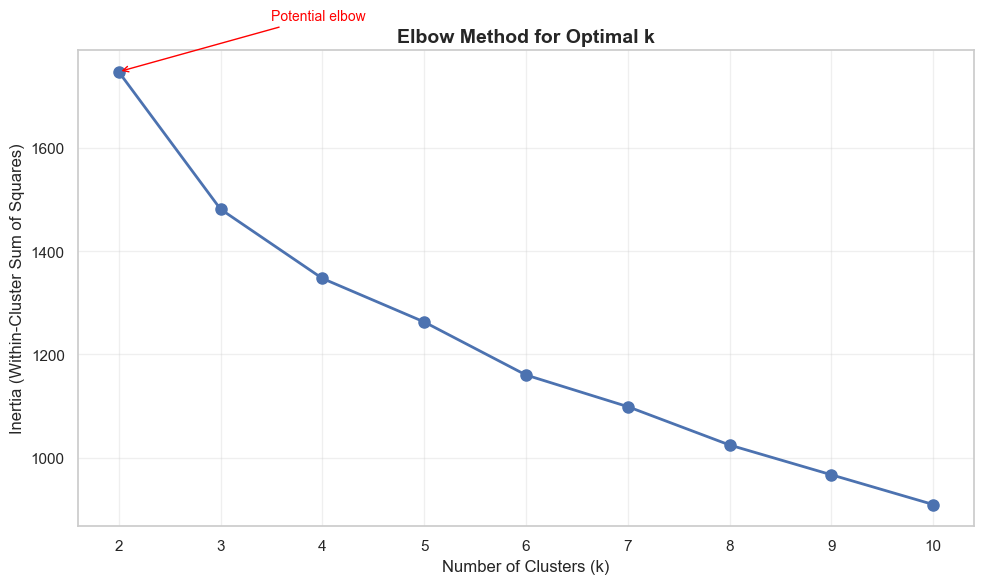


Rate of change in inertia:
k=2 to k=3: -266.04
k=3 to k=4: -134.12
k=4 to k=5: -84.27
k=5 to k=6: -102.72
k=6 to k=7: -61.34
k=7 to k=8: -74.27
k=8 to k=9: -57.70
k=9 to k=10: -57.56


In [287]:
plt.figure(figsize=(10, 6))

plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)

# Annotate the elbow point
plt.annotate('Potential elbow', xy=(2, inertias[0]), xytext=(3.5, inertias[0] + 100),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

plt.tight_layout()
plt.show()

# Calculate rate of change to identify elbow
rate_of_change = np.diff(inertias)
print("\nRate of change in inertia:")
for i, k in enumerate(list(k_range)[:-1]):
    print(f"k={k} to k={k+1}: {rate_of_change[i]:.2f}")

### 3.3 Silhouette Score Analysis

The Silhouette Score evaluates clustering quality by measuring:

- **Cohesion (a)**: average distance between a point and other points in its cluster
- **Separation (b)**: average distance to points in the nearest neighboring cluster

**Mathematical Definition:**

$$s(x_i) = \frac{b(x_i) - a(x_i)}{\max(a(x_i), b(x_i))}$$

**Interpretation:**
| Score Range | Interpretation |
|-------------|----------------|
| 0.71 - 1.00 | Strong cluster structure |
| 0.51 - 0.70 | Reasonable structure |
| 0.26 - 0.50 | Structure might be artificial |
| < 0.26      | No substantial structure |

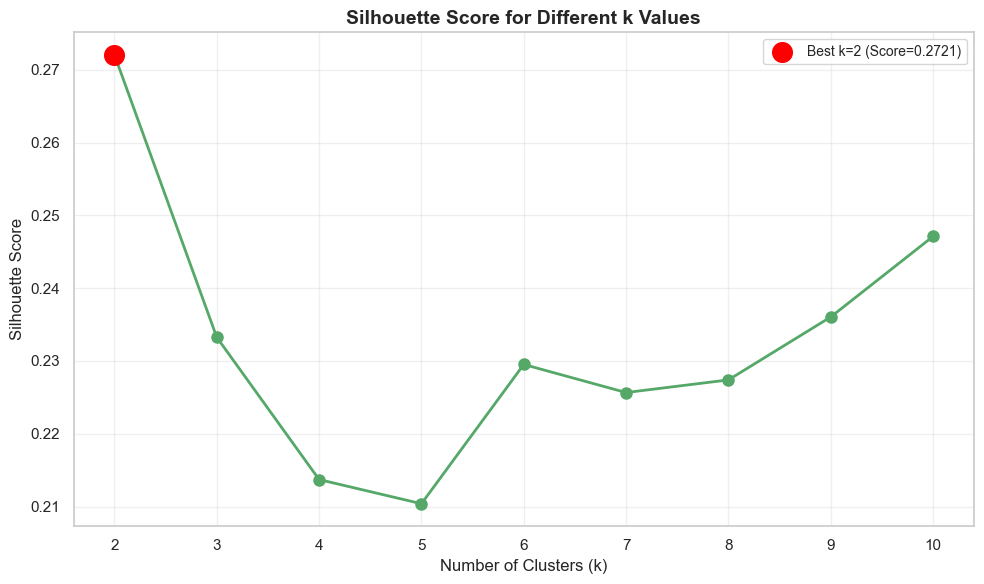

k = 2: 0.2721 - Structure might be artificial
k = 3: 0.2333 - No structure
k = 4: 0.2137 - No structure
k = 5: 0.2104 - No structure
k = 6: 0.2295 - No structure
k = 7: 0.2257 - No structure
k = 8: 0.2274 - No structure
k = 9: 0.2360 - No structure
k = 10: 0.2471 - No structure


In [288]:
plt.figure(figsize=(10, 6))

plt.plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score for Different k Values', fontsize=14, fontweight='bold')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)

# Highlight the maximum silhouette score
max_sil_idx = np.argmax(silhouette_scores)
max_k = list(k_range)[max_sil_idx]
max_sil = silhouette_scores[max_sil_idx]

plt.scatter([max_k], [max_sil], color='red', s=200, zorder=5, label=f'Best k={max_k} (Score={max_sil:.4f})')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
for k, score in zip(k_range, silhouette_scores):
    if score >= 0.71:
        interpretation = "Strong structure"
    elif score >= 0.51:
        interpretation = "Reasonable structure"
    elif score >= 0.26:
        interpretation = "Structure might be artificial"
    else:
        interpretation = "No structure"
    print(f"k = {k}: {score:.4f} - {interpretation}")

### 3.4 Combined Analysis and Optimal k Selection

The Elbow Method and the Silhouette Score are both considered to select the most appropriate number of clusters.

- **Elbow Method:** evaluates how inertia (within-cluster sum of squares) decreases as the number of clusters increases.
- **Silhouette Score:** evaluates how compact and well-separated the clusters are.

In this dataset, the inertia curve shows the largest decrease at the beginning and then flattens gradually, while the highest silhouette score is obtained at **k = 2**. Therefore, **k = 2** is selected as the final number of clusters.

However, the silhouette value is relatively low: this suggests that two groups can be identified, but the separation between them is not very strong.

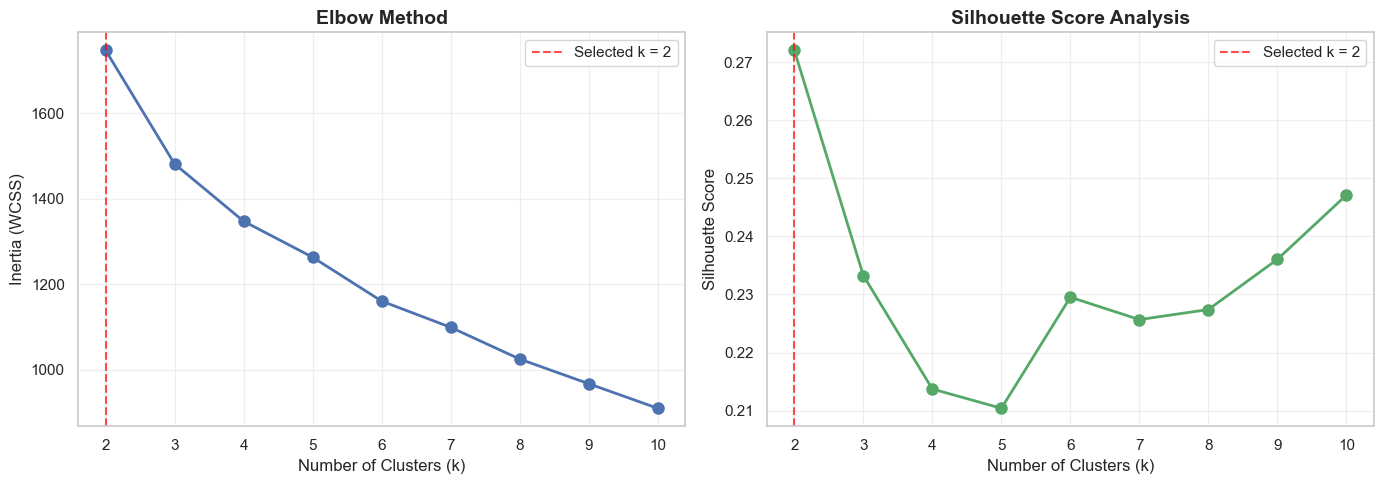


OPTIMAL NUMBER OF CLUSTERS: k = 2
Inertia at k=2: 1747.35
Silhouette Score at k=2: 0.2721


In [289]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(list(k_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Analysis', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

# Calculate optimal k automatically from silhouette score
optimal_k = list(k_range)[np.argmax(silhouette_scores)]

# Add vertical lines at optimal k
axes[0].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k = {optimal_k}')
axes[1].axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Selected k = {optimal_k}')
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

# Print results
print(f'\nOPTIMAL NUMBER OF CLUSTERS: k = {optimal_k}')
print(f'Inertia at k={optimal_k}: {inertias[optimal_k - 2]:.2f}')
print(f'Silhouette Score at k={optimal_k}: {silhouette_scores[optimal_k - 2]:.4f}')

### 3.5 Final K-Means Model (k = 2)

The final K-Means model is fitted using **k = 2**, based on the previous combined analysis.

The goal is to:
- assign each patient to one of the two clusters,
- examine the size of each cluster,
- extract the cluster centers for feature-level description.

K-Means cluster labels are arbitrary, so the description of each cluster will be based on the centroid values rather than on the label number itself.

In [290]:
final_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans_labels = final_kmeans.fit_predict(X_final_scaled)
cluster_centers = final_kmeans.cluster_centers_

unique, counts = np.unique(kmeans_labels, return_counts=True)

print('Final K-Means Model Summary')
print(f'Number of clusters: {optimal_k}')
print(f'Inertia: {final_kmeans.inertia_:.2f}')
print(f'Number of iterations: {final_kmeans.n_iter_}')
print('\nCluster distribution:')
for cluster, count in zip(unique, counts):
    print(f'  Cluster {cluster}: {count} patients ({count / len(kmeans_labels) * 100:.1f}%)')

Final K-Means Model Summary
Number of clusters: 2
Inertia: 1747.35
Number of iterations: 7

Cluster distribution:
  Cluster 0: 121 patients (39.9%)
  Cluster 1: 182 patients (60.1%)


### 3.6 Cluster visualization in PCA space

The selected feature set is projected into two principal components using PCA, the objective is to visualize the clustering result.

This 2D representation is used only for visualization, while clustering itself is still performed on the scaled selected features. The plot helps assess how the two clusters are distributed in reduced-dimensional space and where their centroids are located.

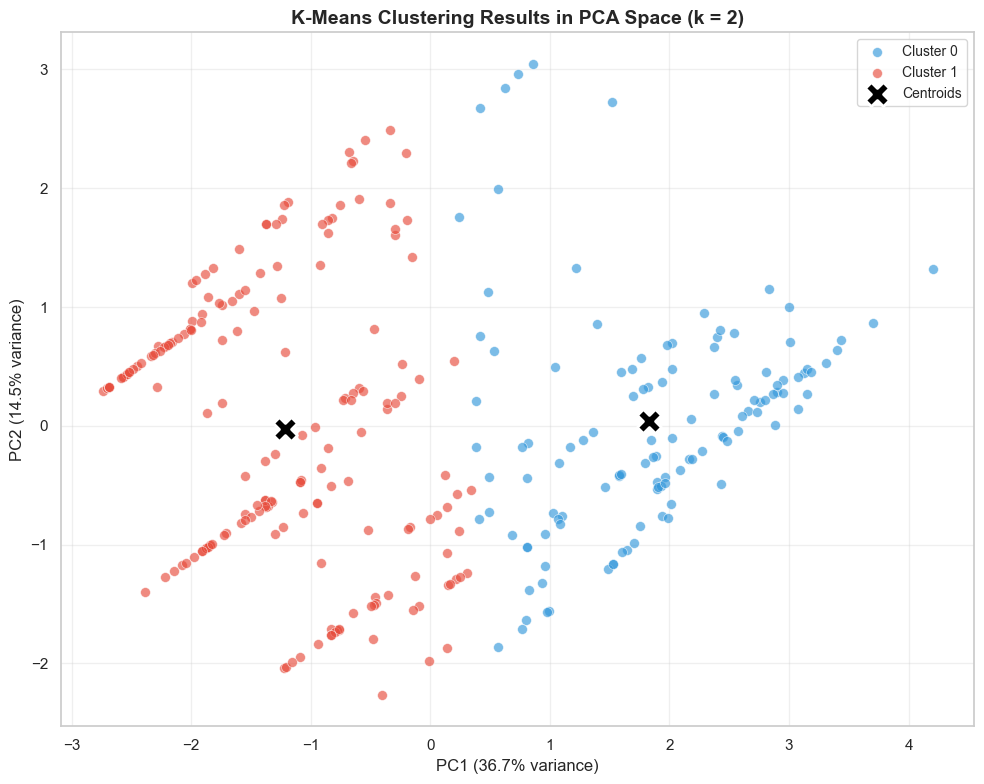

PCA Explained Variance
PC1: 36.75%
PC2: 14.54%
Total: 51.28%


In [291]:
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_final_scaled)
centers_pca = pca_vis.transform(cluster_centers) 

plt.figure(figsize=(10, 8))

colors = ['#3498db', '#e74c3c']
for i in range(optimal_k):
    mask = kmeans_labels == i
    plt.scatter(
        X_pca_vis[mask, 0],
        X_pca_vis[mask, 1],
        c=colors[i],
        label=f'Cluster {i}',
        alpha=0.65,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='black',
    marker='X',
    s=300,
    linewidths=2,
    edgecolors='white',
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0] * 100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1] * 100:.1f}% variance)', fontsize=12)
plt.title(f'K-Means Clustering Results in PCA Space (k = {optimal_k})', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('PCA Explained Variance')
print(f'PC1: {pca_vis.explained_variance_ratio_[0] * 100:.2f}%')
print(f'PC2: {pca_vis.explained_variance_ratio_[1] * 100:.2f}%')
print(f'Total: {sum(pca_vis.explained_variance_ratio_) * 100:.2f}%')

### 3.7 Cluster Centers Interpretation in Original Feature Space

To describe the clusters, the centroid values are examined in both standardized and original feature space, this allows a direct comparison of which selected features are relatively higher or lower in each group.

Cluster Centers - Scaled Values
           thalach  exang  oldpeak     ca  cp_3.0  cp_4.0  slope_2.0  thal_7.0
Cluster 0   -0.710  0.784    0.621  0.532  -0.501   0.803      0.582     0.582
Cluster 1    0.472 -0.521   -0.413 -0.353   0.333  -0.534     -0.387    -0.387

Cluster Centers - Original Scale
           thalach  exang  oldpeak     ca  cp_3.0  cp_4.0  slope_2.0  thal_7.0
Cluster 0  133.388  0.694    1.430  1.165   0.058   0.876      0.752     0.669
Cluster 1  160.390  0.082    0.324  0.341   0.434   0.209      0.269     0.198


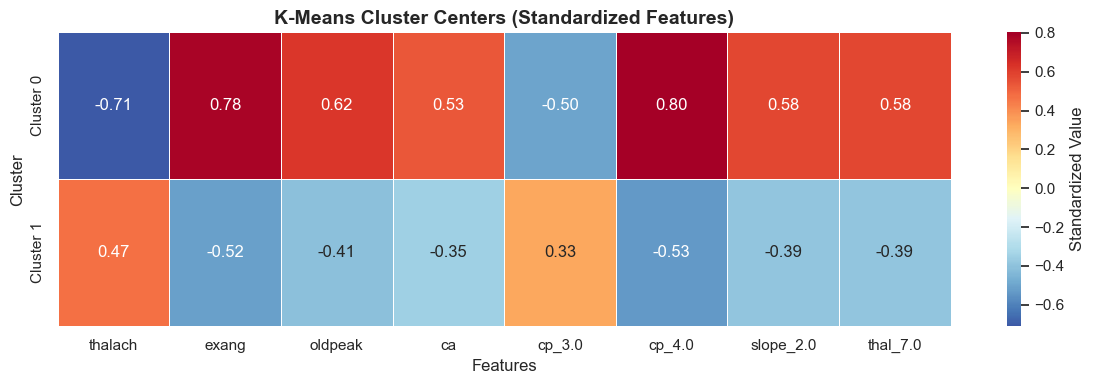

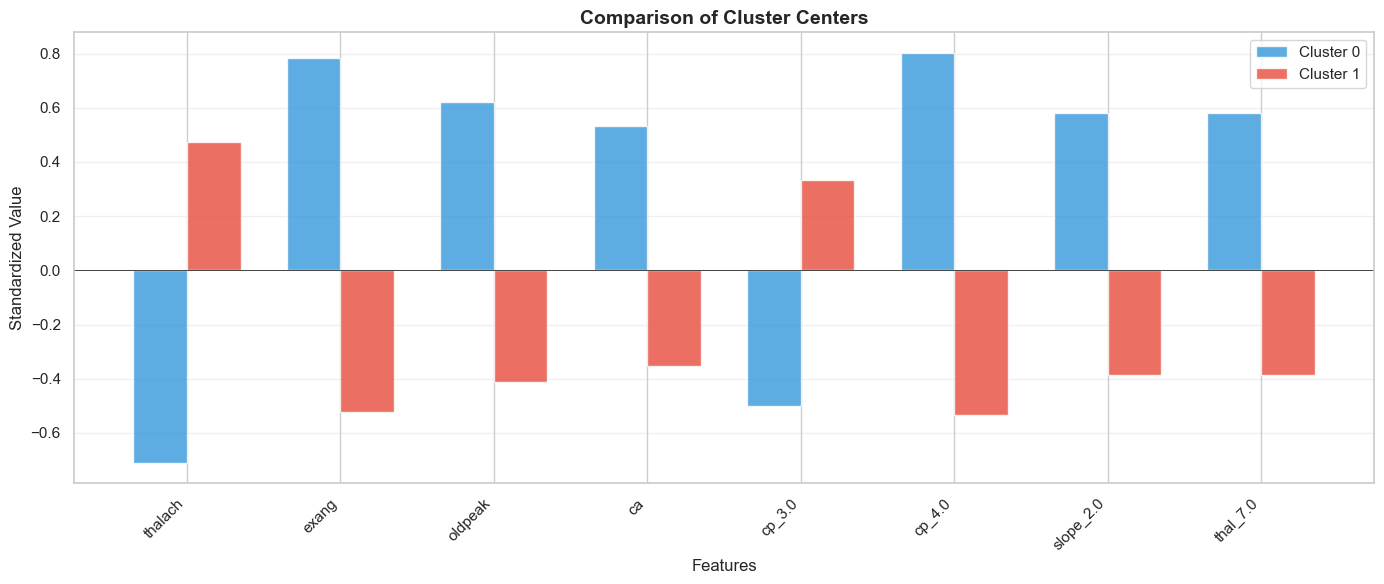

In [292]:
feature_names = list(X_final.columns)

centers_scaled_df = pd.DataFrame(cluster_centers, columns=feature_names)
centers_scaled_df.index = [f'Cluster {i}' for i in range(optimal_k)]

centers_original = scaler_final.inverse_transform(cluster_centers)
centers_original_df = pd.DataFrame(centers_original, columns=feature_names)
centers_original_df.index = [f'Cluster {i}' for i in range(optimal_k)]

print('Cluster Centers - Scaled Values')
print(centers_scaled_df.round(3).to_string())
print('\nCluster Centers - Original Scale')
print(centers_original_df.round(3).to_string())

plt.figure(figsize=(12, 4))
sns.heatmap(
    centers_scaled_df,
    annot=True,
    cmap='RdYlBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Standardized Value'}
)
plt.title('K-Means Cluster Centers (Standardized Features)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(feature_names))
width = 0.35

ax.bar(x - width/2, centers_scaled_df.iloc[0], width, label='Cluster 0', color='#3498db', alpha=0.8)
ax.bar(x + width/2, centers_scaled_df.iloc[1], width, label='Cluster 1', color='#e74c3c', alpha=0.8)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Standardized Value', fontsize=12)
ax.set_title('Comparison of Cluster Centers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

threshold = 0.3

**Interpretation of original-scale centroids**

The cluster centers in the original feature space show the main differences between the two groups: Cluster 0 has lower `thalach` and higher values of `exang`, `oldpeak`, `ca`, `cp_4.0`, `slope_2.0`, and `thal_7.0`, while Cluster 1 shows higher `thalach` and `cp_3.0` and lower values for the other selected features.

In [293]:
print('\nCLUSTER CHARACTERIZATION')
for cluster_name in centers_scaled_df.index:
    center = centers_scaled_df.loc[cluster_name]
    high_features = center[center > threshold].sort_values(ascending=False)
    low_features = center[center < -threshold].sort_values()
    cluster_id = int(cluster_name.split()[-1])
    cluster_count = counts[cluster_id]
    cluster_pct = cluster_count / len(kmeans_labels) * 100
    
    print(f'\n{cluster_name}')
    print(f'Patients in cluster: {cluster_count} ({cluster_pct:.1f}%)')
    
    print('\nFeatures with centroid values above the mean:')
    if len(high_features) > 0:
        for feat, val in high_features.items():
            print(f'- {feat}: {val:.3f}')
    else:
        print('- None')
    
    print('\nFeatures with centroid values below the mean:')
    if len(low_features) > 0:
        for feat, val in low_features.items():
            print(f'- {feat}: {val:.3f}')
    else:
        print('- None')


CLUSTER CHARACTERIZATION

Cluster 0
Patients in cluster: 121 (39.9%)

Features with centroid values above the mean:
- cp_4.0: 0.803
- exang: 0.784
- oldpeak: 0.621
- thal_7.0: 0.582
- slope_2.0: 0.582
- ca: 0.532

Features with centroid values below the mean:
- thalach: -0.710
- cp_3.0: -0.501

Cluster 1
Patients in cluster: 182 (60.1%)

Features with centroid values above the mean:
- thalach: 0.472
- cp_3.0: 0.333

Features with centroid values below the mean:
- cp_4.0: -0.534
- exang: -0.521
- oldpeak: -0.413
- thal_7.0: -0.387
- slope_2.0: -0.387
- ca: -0.353


### 3.8 Summary of K-Means Clustering Results

The K-Means analysis was performed for values of **k** from 2 to 10 using the scaled feature set selected in Task 2.

Main findings:

1. **Optimal number of clusters:**  
   **k = 2** was selected because it gave the highest silhouette score among the tested values and showed the clearest reduction pattern in the inertia curve.

2. **Cluster structure:**  
   The two-cluster solution separates the data into two groups, although the silhouette score indicates limited separation.

3. **PCA visualization:**  
   The PCA projection shows partial overlap between the two clusters, which is consistent with limited separation in two-dimensional space.

4. **Cluster description:**  
   The two clusters differ mainly in the centroid values of **thalach, exang, oldpeak, ca, cp3.0, cp4.0, slope2.0, and thal7.0**. One cluster has lower **thalach** and higher values for several of the other selected variables, while the other cluster shows the opposite pattern.

Overall, K-Means provides a two-group partition of the dataset based on the selected feature set, and the centroid comparison helps describe the main differences between the groups.

In [294]:
# Save Results
results_summary = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette_Score': silhouette_scores
})

print('K-Means Results Summary')
print(results_summary.to_string(index=False))

K-Means Results Summary
 k     Inertia  Silhouette_Score
 2 1747.350171          0.272055
 3 1481.308829          0.233258
 4 1347.189271          0.213718
 5 1262.923905          0.210398
 6 1160.204419          0.229525
 7 1098.867249          0.225667
 8 1024.599976          0.227403
 9  966.899011          0.236049
10  909.340248          0.247111


## Task 4 — Clustering: Gaussian Mixture Models (Ana)

In this section GMM clustering will be used to discover patient subgroups from the preprocessed feature set.

### Subtasks
- Fit GMMs with a varying number of components (2 to 10).
- Use BIC or AIC to select the optimal number of components. 
- Plot the selected method curve.
- Visualize the cluster assignments by projecting the data into PCA space (2D).
- Interpret the cluster centres directly in the original feature space
- Compare the hard cluster assignments from GMM with K-Means.

In [295]:
from sklearn.mixture import GaussianMixture

### 4.1 GMM Clustering for k = 2 to 10
We applied Gaussian Mixture Model (GMM) clustering for different values of \(k\) (number of clusters) ranging from 2 to 10.

For each value of \(k\), we computed:

- **BIC (Bayesian Information Criterion)**: evaluates model fit while penalizing model complexity (lower values indicate a better trade-off between fit and simplicity).  
- **AIC (Akaike Information Criterion)**: evaluates model fit with a different complexity penalty (lower values indicate better model).  

In addition, to further evaluate cluster quality, we computed:

- **Log-Likelihood**: measures how likely the observed data is under the fitted model; higher values indicate a better fit.  
- **Silhouette Score**: based on hard cluster assignments (assigning each point to the cluster with highest probability), this score measures how well-separated and cohesive the clusters are. Values close to 1 indicate well-separated clusters, values near 0 indicate overlapping clusters, and negative values indicate misassigned points.

In [296]:
# Define the range of cluster numbers to evaluate
components = range(2, 11)

# Lists to store metrics for each k
bic_scores = [] 
aic_scores = []
silhouette_scores = []
log_likelihood = []

# Loop over each k and fit GMM
for k in components: 
    gmm = GaussianMixture(n_components=k, n_init=10, max_iter = 300, random_state=42) 
    gmm.fit(X_final_scaled) 
    
    # Compute BIC and AIC to evaluate model fit and complexity
    bic = gmm.bic(X_final_scaled)
    aic = gmm.aic(X_final_scaled)
    
    bic_scores.append(bic) 
    aic_scores.append(aic)

    # Compute log-likelihood as a measure of model fit (higher is better)
    loglikelihood = gmm.score(X_final_scaled) * len(X_final_scaled)
    log_likelihood.append(loglikelihood)
    
    # Compute silhouette score using hard cluster assignments
    # Measures cluster cohesion and separation
    labels = gmm.predict(X_final_scaled)
    silhouette = silhouette_score(X_final_scaled, labels)
    silhouette_scores.append(silhouette)
    
    # Print metrics for this k
    print(f"k = {k}: AIC = {aic:.2f}, BIC = {bic:.4f}, Silhouette = {silhouette:.4f}, Loglikelihood = {loglikelihood:.4f}")

# Select best k according to BIC and AIC
best_k_bic = components[np.argmin(bic_scores)]
best_k_aic = components[np.argmin(aic_scores)]
print(100*"-")
print(f"{best_k_bic} is the best number of components according to BIC")
print(f"{best_k_aic} is the best number of components according to AIC")

k = 2: AIC = 435.16, BIC = 765.6866, Silhouette = 0.2414, Loglikelihood = -128.5822
k = 3: AIC = -1667.19, BIC = -1169.5479, Silhouette = 0.1920, Loglikelihood = 967.5941
k = 4: AIC = -3549.75, BIC = -2884.9949, Silhouette = 0.2100, Loglikelihood = 1953.8765
k = 5: AIC = -5080.28, BIC = -4248.4043, Silhouette = 0.2014, Loglikelihood = 2764.1402
k = 6: AIC = -4757.63, BIC = -3758.6360, Silhouette = 0.1888, Loglikelihood = 2647.8151
k = 7: AIC = -6001.40, BIC = -4835.2872, Silhouette = 0.1868, Loglikelihood = 3314.6997
k = 8: AIC = -6422.26, BIC = -5089.0261, Silhouette = 0.2151, Loglikelihood = 3570.1281
k = 9: AIC = -7222.65, BIC = -5722.3030, Silhouette = 0.2313, Loglikelihood = 4015.3255
k = 10: AIC = -7986.49, BIC = -6319.0207, Silhouette = 0.2300, Loglikelihood = 4442.2433
----------------------------------------------------------------------------------------------------
10 is the best number of components according to BIC
10 is the best number of components according to AIC


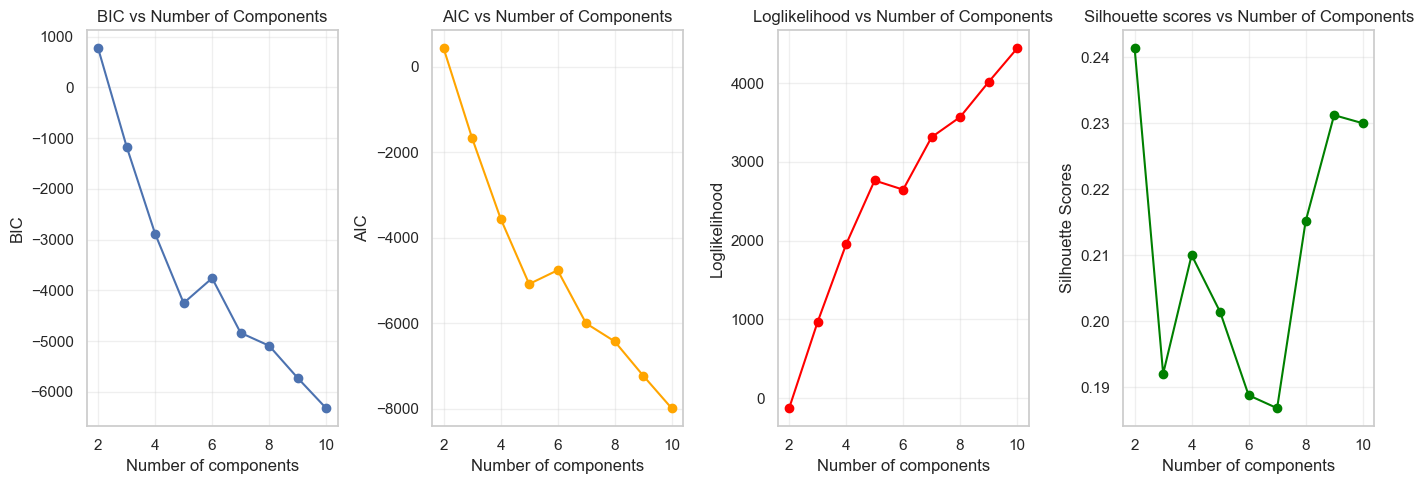

In [297]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5)) # 1 row and 4 columns

# BIC
axes[0].plot(components, bic_scores, marker='o')
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC vs Number of Components")
axes[0].grid(True, alpha=0.3)

# AIC
axes[1].plot(components, aic_scores, marker='o', color='orange')
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("AIC")
axes[1].set_title("AIC vs Number of Components")
axes[1].grid(True, alpha=0.3)

# Loglikelihood
axes[2].plot(components, log_likelihood, marker='o', color='red')
axes[2].set_xlabel("Number of components")
axes[2].set_ylabel("Loglikelihood")
axes[2].set_title("Loglikelihood vs Number of Components")
axes[2].grid(True, alpha=0.3)

# Silhouette score with hard assignments
axes[3].plot(components, silhouette_scores, marker='o', color='green')
axes[3].set_xlabel("Number of components")
axes[3].set_ylabel("Silhouette Scores")
axes[3].set_title("Silhouette scores vs Number of Components")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Although AIC and BIC continue decreasing as `k` increases, with a small peak in the middle, this likely reflects overfitting rather than a meaningful improvement. 

While the silhouette score is highest for `k = 2`, it fluctuates across different values of `k`, suggesting that the data may not have a strongly defined cluster structure. 

Additionally, the log-likelihood increases with `k`, again with a small peak in the middle, which is expected as more components allow the model to better fit the data.

Since choosing the best `k` based solely on the metrics plots is difficult, we will also explore how well each number of components separates the data by projecting it into PCA space (2D).

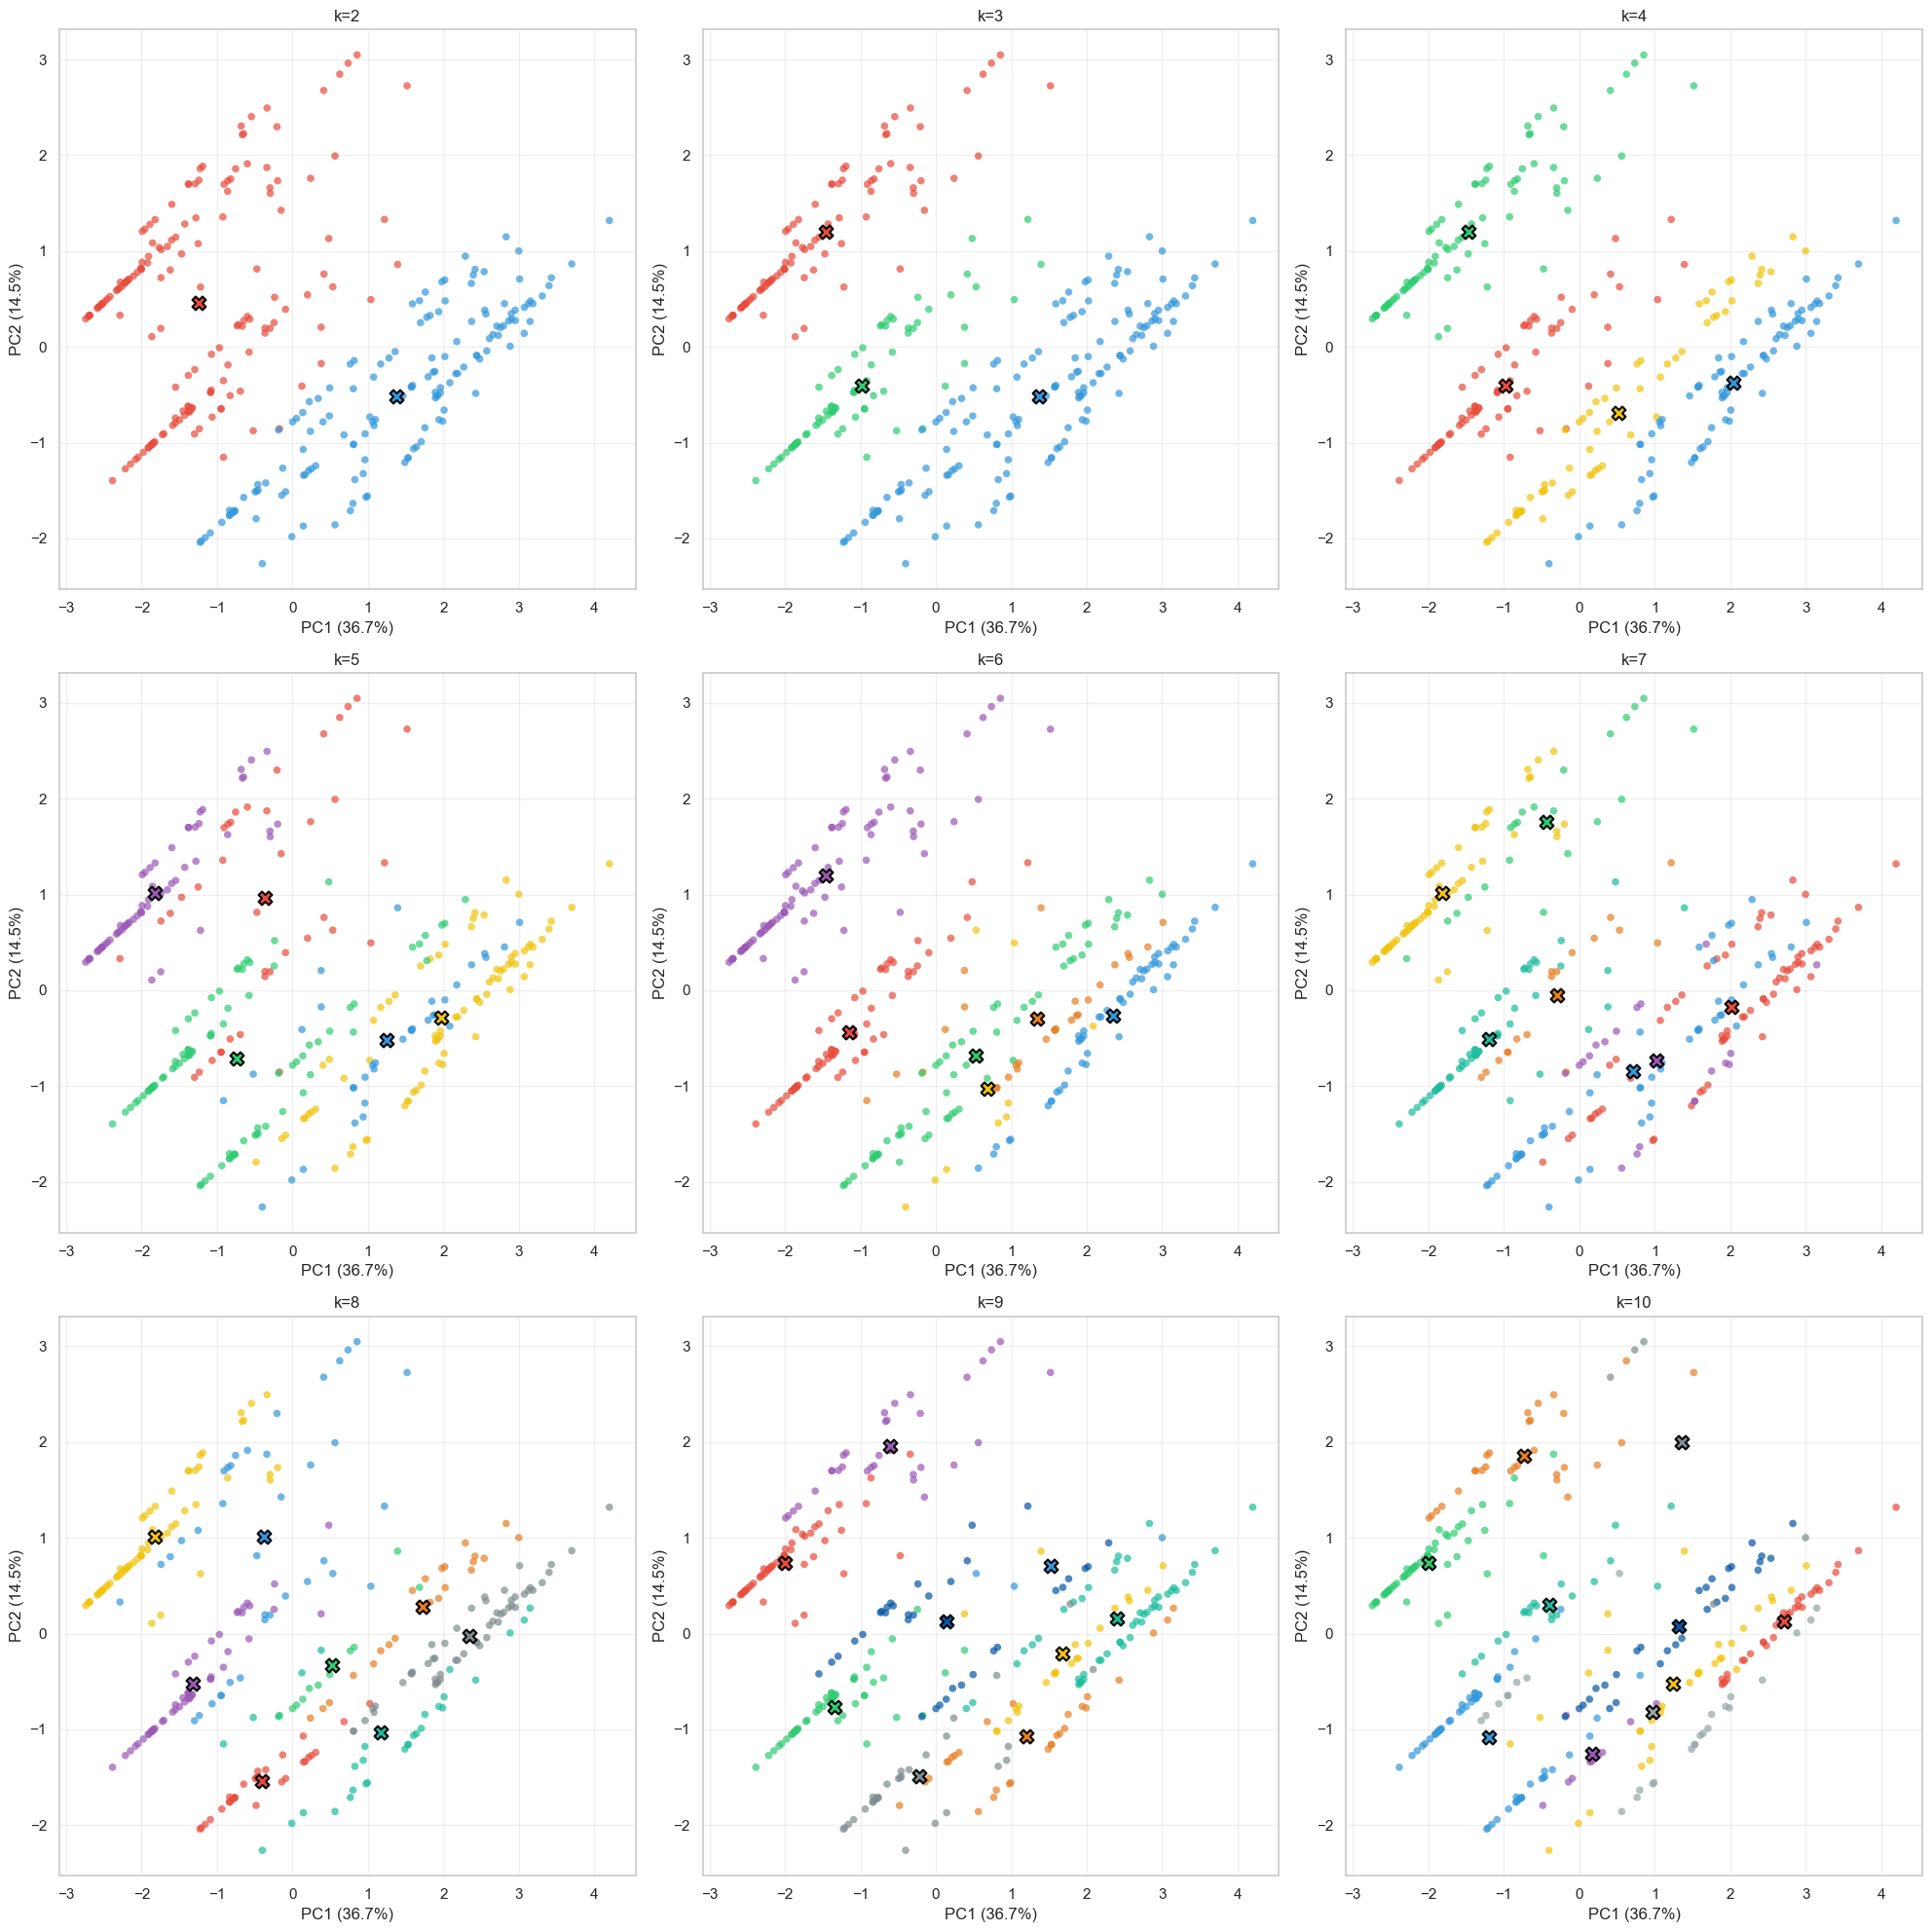

In [298]:
# Base colors (max 10 clusters)
base_colors = np.array([
    [52, 152, 219],   # blue
    [231, 76, 60],    # red
    [46, 204, 113],   # green
    [241, 196, 15],   # yellow
    [155, 89, 182],   # purple
    [230, 126, 34],   # orange
    [26, 188, 156],   # turquoise
    [127, 140, 141],  # gray
    [4, 85, 165],     # dark blue
    [149, 165, 166]   # light gray
]) / 255

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final_scaled)

# Create figure with 3 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(20,20))
axes = axes.flatten()  # Flatten to iterate easily

for idx, k in enumerate(range(2, 11)):
    ax = axes[idx]
    
    # Fit GMM
    gmm = GaussianMixture(n_components=k, n_init=10, random_state=42)
    labels = gmm.fit_predict(X_final_scaled)
    probs = gmm.predict_proba(X_final_scaled)
    
    # Compute colors as weighted sum
    colors_rgb = probs @ base_colors[:k]
    
    # Scatter plot
    ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        color=colors_rgb,
        s=30,
        edgecolors='none',
        alpha=0.7
    )
    
    # Plot cluster centers in PCA space
    centers_pca = pca.transform(gmm.means_)
    for i, center in enumerate(centers_pca):
        ax.scatter(center[0], center[1],
                   c=[base_colors[i]],
                   marker='X',
                   s=100,
                   edgecolors='black',
                   linewidth=1.5)
    
    ax.set_title(f"k={k}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.grid(True, alpha=0.3)

# Hide any unused axes if k < 10
for j in range(idx+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Among the values `k ≤ 10`, `k = 4` provided a good balance across all evaluation metrics (AIC, BIC, silhouette score, and log-likelihood).

Additionally, visual inspection in PCA space showed that `k = 4` results in a clearer separation of clusters, with fewer overlaps compared to other values, while acknowledging that the full feature space contains additional variance not captured in the 2D projection. Therefore, `k = 4` was selected as a more meaningful solution.

### 4.2 Final GMM Model (k = 4)

The final GMM model is fitted using **k = 4**, based on the previous combined analysis.

The goal is to:
- assign each patient to one of the 4 clusters,
- examine the size of each cluster,
- extract the cluster centers (means) for feature-level description.

In [299]:
best_k = 4
final_gmm = GaussianMixture(n_components=best_k, n_init=10, max_iter = 300, random_state=42) 

gmm_labels = final_gmm.fit_predict(X_final_scaled)
cluster_centers = final_gmm.means_

unique, counts = np.unique(gmm_labels, return_counts=True)

print('Final GMM Model Summary')
print(f'Number of clusters: {best_k}')
print(f'Number of iterations: {final_gmm.n_iter_}')
print('\nCluster distribution:')
for cluster, count in zip(unique, counts):
    print(f'  Cluster {cluster}: {count} patients ({count / len(gmm_labels) * 100:.1f}%)')

Final GMM Model Summary
Number of clusters: 4
Number of iterations: 9

Cluster distribution:
  Cluster 0: 80 patients (26.4%)
  Cluster 1: 73 patients (24.1%)
  Cluster 2: 86 patients (28.4%)
  Cluster 3: 64 patients (21.1%)


### 4.3 Cluster visualization in PCA space

The selected feature set is projected into two principal components using PCA, the objective is to visualize the clustering result.

This 2D representation is used only for visualization, while clustering itself is still performed on the scaled selected features. The plot helps assess how the four clusters are distributed in reduced-dimensional space and where their centers are located.

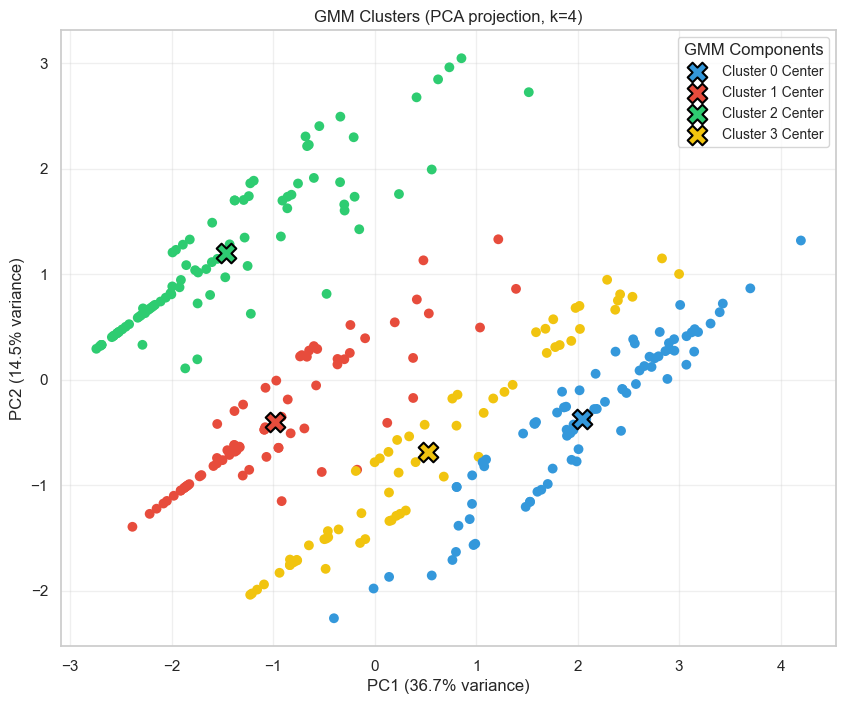

In [300]:
# Probabilities of belonging to each cluster
probs = final_gmm.predict_proba(X_final_scaled)  # shape (n_samples, n_clusters)

# PCA to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final_scaled)

# Base colors for each cluster (RGB normalized)
base_colors = np.array([
    [52, 152, 219],   # blue
    [231, 76, 60],    # red
    [46, 204, 113],   # green
    [241, 196, 15],   # yellow
    [155, 89, 182],   # purple
    [230, 126, 34],   # orange
    [26, 188, 156],   # turquoise
    [127, 140, 141],  # gray
    [4, 85, 165],     # dark blue
    [149, 165, 166]   # light gray
]) / 255  # normalize to 0-1

# Weight colors by cluster probabilities
colors_rgb = probs @ base_colors[:best_k]

# Ensure dtype is float32 for matplotlib
colors_rgb = colors_rgb.astype(float)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    color=colors_rgb, 
    s=50, 
    edgecolors='none'  # remove white edges to see gradient
)

# Optional: plot cluster means
centers_pca = pca.transform(final_gmm.means_)

# Plot each cluster center with its base color
for i, center in enumerate(centers_pca):
    plt.scatter(center[0], center[1], 
                c=[base_colors[i]],  # use the cluster color
                marker='X', 
                s=200, 
                edgecolors='black', 
                linewidth=1.5,
                label=f'Cluster {i} Center')
    
plt.legend(title="GMM Components", fontsize=10)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title(f"GMM Clusters (PCA projection, k={best_k})")
plt.grid(True, alpha=0.3)
plt.show()

### 4.4 Cluster Centers Interpretation in Original Feature Space

To describe the clusters, the center values are examined in both standardized and original feature space, this allows a direct comparison of which selected features are relatively higher or lower in each group.

Cluster Centers - Scaled Values
           thalach  exang  oldpeak     ca  cp_3.0  cp_4.0  slope_2.0  thal_7.0
Cluster 0   -0.663  1.435    0.500  0.314  -0.630   1.051      0.427     0.542
Cluster 1    0.472 -0.463   -0.332 -0.293  -0.630  -0.952     -0.295    -0.315
Cluster 2    0.254 -0.424   -0.227 -0.232   1.588  -0.952     -0.157    -0.268
Cluster 3   -0.051 -0.697    0.058  0.254  -0.630   1.051      0.013     0.041

Cluster Centers - Original Scale
           thalach  exang  oldpeak     ca  cp_3.0  cp_4.0  slope_2.0  thal_7.0
Cluster 0  134.462  1.000    1.300  0.963     0.0     1.0      0.675     0.650
Cluster 1  160.384  0.110    0.411  0.397     0.0     0.0      0.315     0.233
Cluster 2  155.407  0.128    0.523  0.453     1.0     0.0      0.384     0.256
Cluster 3  148.453  0.000    0.828  0.906     0.0     1.0      0.469     0.406


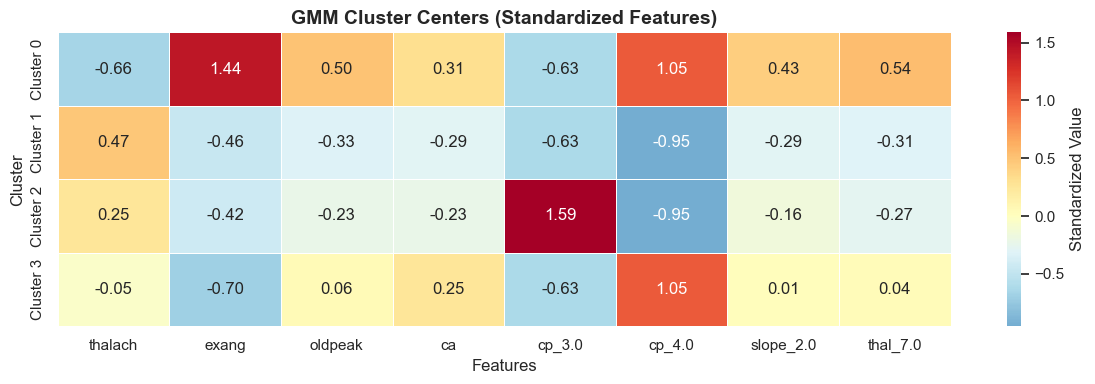

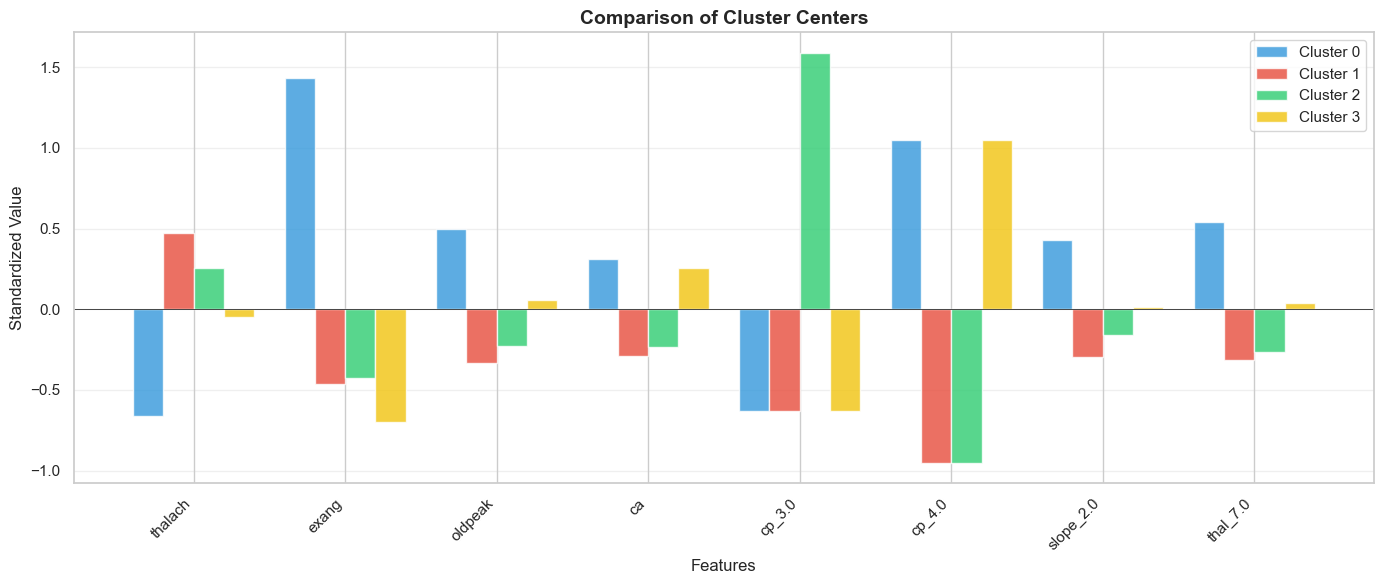

In [301]:
component_centers = final_gmm.means_
component_centers_original = scaler_final.inverse_transform(final_gmm.means_)

feature_names = list(X_final.columns)

centers_scaled_df = pd.DataFrame(component_centers, columns=feature_names)
centers_scaled_df.index = [f'Cluster {i}' for i in range(best_k)]

centers_original = scaler_final.inverse_transform(component_centers)
centers_original_df = pd.DataFrame(centers_original, columns=feature_names)
centers_original_df.index = [f'Cluster {i}' for i in range(best_k)]

print('Cluster Centers - Scaled Values')
print(centers_scaled_df.round(3).to_string())
print('\nCluster Centers - Original Scale')
print(centers_original_df.round(3).to_string())

plt.figure(figsize=(12, 4))
sns.heatmap(
    centers_scaled_df,
    annot=True,
    cmap='RdYlBu_r',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Standardized Value'}
)
plt.title('GMM Cluster Centers (Standardized Features)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Cluster', fontsize=12)
plt.tight_layout()
plt.show()

base_colors = [
    '#3498db',  # blue
    '#e74c3c',  # red
    '#2ecc71',  # green
    '#f1c40f',  # yellow
    '#9b59b6',  # purple
    '#e67e22',  # orange
    '#1abc9c',  # turquoise
    '#7f8c8d',  # gray
    "#0455a5",  # dark blue
    '#95a5a6'   # light gray
]
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(feature_names))
width = 0.8 / best_k  

for i in range(best_k):
    ax.bar(x + (i - best_k/2)*width + width/2, 
           centers_scaled_df.iloc[i], 
           width, 
           label=f'Cluster {i}', 
           color=base_colors[i], 
           alpha=0.8)

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Standardized Value', fontsize=12)
ax.set_title('Comparison of Cluster Centers', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Interpretation of Original-Scale Centers

We observe that the features *oldpeak*, *thal_7.0*, and *ca* show similar patterns across clusters, suggesting less variation in these variables. In contrast, most of the variability between clusters is driven by *thalach*, *exang*, *cp_3.0*, and *cp_4.0*.

- **Cluster 0** shows higher values in most features, except for *thalach* and *cp_3.0*.  
- **Cluster 1** is mainly characterized by higher values in *thalach*.  
- **Cluster 2** shows higher values in *thalach* and *cp_3.0*.  
- **Cluster 3** has higher values in most features, except for *thalach*, *exang*, and *cp_3.0*.  

In [302]:
threshold = 0.3
print('\nCLUSTER CHARACTERIZATION')
for cluster_name in centers_scaled_df.index:
    center = centers_scaled_df.loc[cluster_name]
    high_features = center[center > threshold].sort_values(ascending=False)
    low_features = center[center < -threshold].sort_values()
    cluster_id = int(cluster_name.split()[-1])
    cluster_count = counts[cluster_id]
    cluster_pct = cluster_count / len(kmeans_labels) * 100
    
    print(f'\n{cluster_name}')
    print(f'Patients in cluster: {cluster_count} ({cluster_pct:.1f}%)')
    
    print('\nFeatures with centers values above the mean:')
    if len(high_features) > 0:
        for feat, val in high_features.items():
            print(f'- {feat}: {val:.3f}')
    else:
        print('- None')
    
    print('\nFeatures with centers values below the mean:')
    if len(low_features) > 0:
        for feat, val in low_features.items():
            print(f'- {feat}: {val:.3f}')
    else:
        print('- None')


CLUSTER CHARACTERIZATION

Cluster 0
Patients in cluster: 80 (26.4%)

Features with centers values above the mean:
- exang: 1.435
- cp_4.0: 1.051
- thal_7.0: 0.542
- oldpeak: 0.500
- slope_2.0: 0.427
- ca: 0.314

Features with centers values below the mean:
- thalach: -0.663
- cp_3.0: -0.630

Cluster 1
Patients in cluster: 73 (24.1%)

Features with centers values above the mean:
- thalach: 0.472

Features with centers values below the mean:
- cp_4.0: -0.952
- cp_3.0: -0.630
- exang: -0.463
- oldpeak: -0.332
- thal_7.0: -0.315

Cluster 2
Patients in cluster: 86 (28.4%)

Features with centers values above the mean:
- cp_3.0: 1.588

Features with centers values below the mean:
- cp_4.0: -0.952
- exang: -0.424

Cluster 3
Patients in cluster: 64 (21.1%)

Features with centers values above the mean:
- cp_4.0: 1.051

Features with centers values below the mean:
- exang: -0.697
- cp_3.0: -0.630


### 4.5 Summary of GMM Clustering Results

The GMM analysis was performed for values of **k** from 2 to 10 using the scaled feature set selected in Task 2.

**Main findings:**

1. **Optimal number of clusters:**  
   **k = 4** was selected. While metrics such as AIC, BIC, log-likelihood, and Silhouette score suggested improvements with increasing k, this mainly reflected overfitting. The PCA 2D visualization was used to support the choice, showing that four clusters form distinct, elongated ellipses with minimal overlap, providing a clearer and more interpretable separation.

2. **Cluster structure:**  
   The 4-cluster solution separates the data into four groups of roughly similar size (21–28% each), although some overlap remains.

3. **PCA visualization:**  
   The 2D PCA projection shows that most points are clearly grouped, with minimal overlap between clusters. The four GMM clusters form four elongated, parallel ellipses, with their major axes aligned along a direction with an approximate slope of 1.

4. **Cluster description:**  
   Clusters differ mainly in chest pain type (cp_*), exercise-induced angina (exang), and maximum heart rate (thalach), while features such as oldpeak, thal_7.0, and ca show more similar patterns across clusters.
   Cluster 0 is characterized by higher-risk indicators (e.g., exang and cp_4.0), whereas clusters 1–3 exhibit different combinations of thalach and chest pain-related features, reflecting more moderate or distinct cardiac profiles.

**Conclusion:**  
GMM provides a meaningful four-group partition of the dataset based on the selected feature set. Examining the cluster centers (means) helps highlight the main differences between the groups.

### 4.6 Comparison with K-means (k = 2)

Cluster assignment comparison (counts):
GMM      0   1   2   3
KMeans                
0       77   8   7  29
1        3  65  79  35


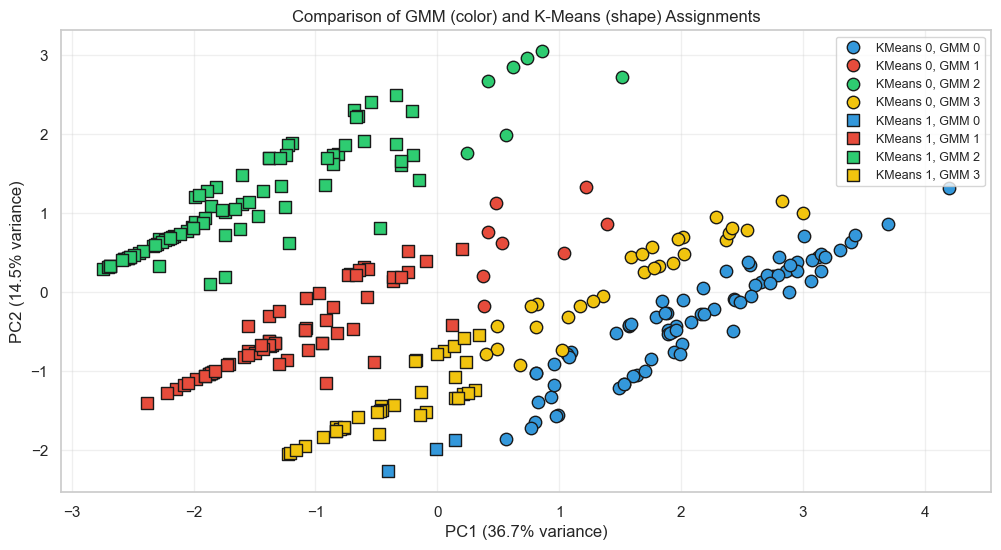

In [303]:
# --- Fit K-Means ---
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_labels = kmeans.fit_predict(X_final_scaled)

# --- Fit GMM ---
gmm = GaussianMixture(n_components=4, n_init=10, max_iter=300, random_state=42)
gmm_labels = gmm.fit_predict(X_final_scaled)

# --- Cross-tab to compare clusters ---
comparison_table = pd.crosstab(kmeans_labels, gmm_labels,
                               rownames=['KMeans'], colnames=['GMM'])
print("Cluster assignment comparison (counts):")
print(comparison_table)

# --- PCA for visualization ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final_scaled)

# --- Base colors for GMM clusters (RGB normalized) ---
gmm_colors = np.array([
    [52, 152, 219],   # blue
    [231, 76, 60],    # red
    [46, 204, 113],   # green
    [241, 196, 15],   # yellow
]) / 255

# --- Markers for K-Means clusters ---
kmeans_markers = ['o', 's']  # 2 markers for K-Means

plt.figure(figsize=(12, 6))

for kmeans_cluster in range(2):
    for gmm_cluster in range(4):
        mask = (kmeans_labels == kmeans_cluster) & (gmm_labels == gmm_cluster)
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=[gmm_colors[gmm_cluster]],   # color by GMM
            marker=kmeans_markers[kmeans_cluster],  # shape by K-Means
            edgecolor='k',
            s=80,
            label=f'KMeans {kmeans_cluster}, GMM {gmm_cluster}'
        )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Comparison of GMM (color) and K-Means (shape) Assignments")

# Remove duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize=9)

plt.grid(True, alpha=0.3)
plt.show()

Although the comparison is challenging due to the different number of components (K-Means: k = 2, GMM: k = 4), we can observe that K-Means roughly separates the data into two groups, with one cluster on the left and the other on the right, as if there were an imaginary vertical boundary between them.

In contrast, the four GMM clusters form four elongated, roughly parallel ellipses, with their major axes aligned along a direction with an approximate slope of 1.